# TP1 -- Série de Fourier

**Ce notebook est un compagnon d'exécution, pas le sujet.** Le sujet de
référence, questions complètes, contexte, rappels, est **`TP1.pdf`**.
Gardez-le ouvert à côté : les cellules ci-dessous sont repérées par leur
numéro de question dans le PDF (A1, A2, B1, ...) et n'en reprennent que
l'essentiel.

Toutes les fonctions dont vous avez besoin sont déjà écrites dans
`tp1_helpers.py`. Vous n'avez pas à les modifier : votre travail est de
faire tourner les cellules, changer les valeurs indiquées, lire les
tracés, et répondre aux questions du PDF.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tp1_helpers import (
    make_square, make_random_walk, make_exotique, make_sawtooth,
    fourier_coeffs, reconstruct, parseval_energy, signal_energy,
    plot_signal, plot_spectrum, plot_reconstruction,
)

## A --- Première manipulation de séries trigonométriques

### A1-A2 : sinus et cosinus

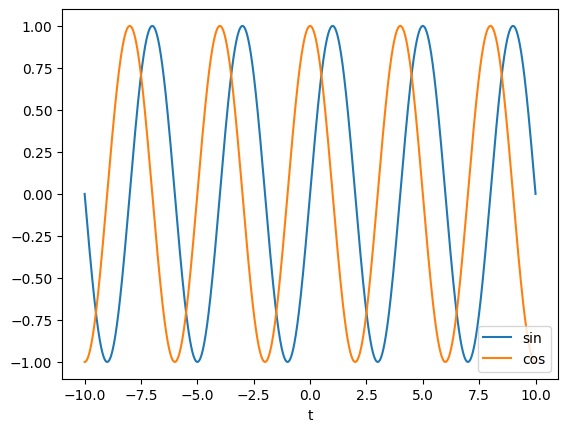

In [2]:
f = 0.250
t = np.linspace(-10, 10, 2000)
plt.plot(t, np.sin(2 * np.pi * f * t), label="sin")
plt.plot(t, np.cos(2 * np.pi * f * t), label="cos")
plt.xlabel("t")
plt.legend()
plt.show()

_Réponse A2 :_

### A3 : même chose à 440 Hz, puis zoom

On trace sur une fenêtre large, puis on zoome avec `xlim` -- pas besoin de
refaire le tracé, changez juste les bornes et ré-exécutez.

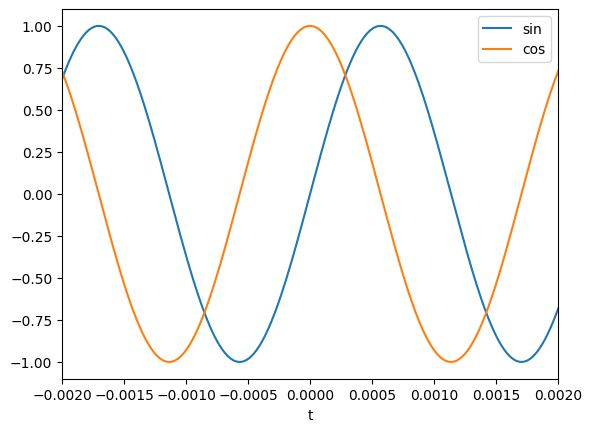

In [3]:
f = 440.0
t = np.linspace(-0.02, 0.02, 4000)
plt.plot(t, np.sin(2 * np.pi * f * t), label="sin")
plt.plot(t, np.cos(2 * np.pi * f * t), label="cos")
plt.xlabel("t")
plt.legend()
plt.xlim(-0.002, 0.002)  # <- zoom sur ~une période : modifiez ces bornes et ré-exécutez
plt.show()

_Réponse A3 :_

### A4 : une série qui ne vient d'aucun signal

$T=1$, $a_n=b_n=1$ pour tout $n$. Choisissez une valeur de $N$, regardez,
recommencez avec une autre valeur.

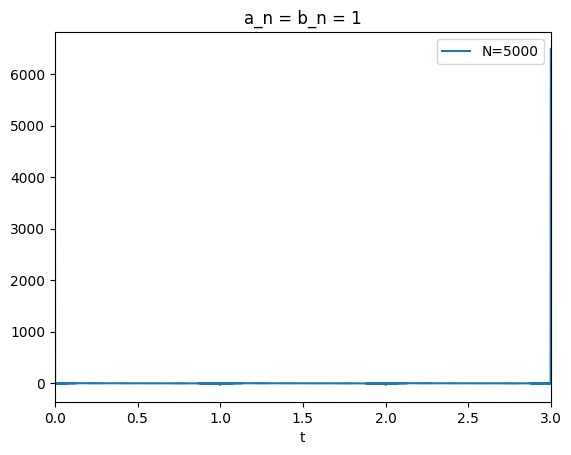

In [63]:
T = 1.0
t = np.linspace(0, 3*T, 2000)
N =  5000# <- modifiez cette valeur (essayez 1, 2, 5, 20, 100) et ré-exécutez
n = np.arange(N)
an = 1.0001**n
bn = 0.5**n


y = reconstruct(t, T, a0=0.0, an=an, bn=bn)
plot_reconstruction(t, {f"N={N}": y}, title="a_n = b_n = 1")
plt.xlim(0,3)
plt.show()

Cas extrême, pour finir :

In [ ]:
N = 100000
an = np.ones(N)
bn = np.ones(N)
y = reconstruct(t, T, a0=0.0, an=an, bn=bn)  # quelques secondes
plt.plot(t, y)
plt.title(f"N={N}")
plt.show()

_Réponse A4 :_

## B --- Analyse et synthèse d'un signal périodique par série de Fourier

### B1 : le signal carré

In [ ]:
carre = make_square(T=1.0, A=1.0)
plot_signal(carre, tmin=-2, tmax=2, npts=2000)  # <- modifiez tmin/tmax pour zoomer/dézoomer
plt.show()

### B2 : coefficients de Fourier

In [ ]:
a0, an, bn = fourier_coeffs(carre, N=1000)
print("a0 =", a0)
print("b1..b5 =", bn[:5])

_Réponse B2 :_

### B3 : spectre

In [ ]:
plot_spectrum(an, bn)
plt.show()

### B4 : reconstruction

Choisissez une valeur de $N$, regardez, recommencez avec une autre valeur.

In [ ]:
t = np.linspace(-2, 2, 2000)
original = [carre.f(ti) for ti in t]
N = 10  # <- modifiez cette valeur (essayez 2, 5, 10, 100) et ré-exécutez
a0_N, an_N, bn_N = fourier_coeffs(carre, N=N)  # recalculés pour ce N
y = reconstruct(t, carre.T, a0_N, an_N, bn_N, orders=range(1, N + 1))
plot_reconstruction(t, {f"N={N}": y}, original=original,
                     xlim=(-0.2, 0.2))  # <- zoomez près d'un saut pour observer Gibbs
plt.show()

_Réponse B4 :_

### B5 : reconstruction avec des rangs élevés seulement

In [ ]:
n_min, n_max =10,100  # <- modifiez ces bornes et ré-exécutez
y_partiel = reconstruct(t, carre.T, a0, an, bn,
                         orders=range(n_min, n_max + 1), include_dc=False)
plot_reconstruction(t, {f"rangs {n_min}-{n_max}": y_partiel}, original=original)
plt.show()

_Réponse B5 :_

## C --- Deux signaux à l'allure trompeuse

On traite les deux signaux l'un après l'autre, en entier, plutôt qu'en
parallèle.

### C1-C2 : la marche aléatoire

In [ ]:
marche = make_random_walk(T=1.0, n_points=25, seed=42)
plot_signal(marche, tmin=0, tmax=3, npts=3000)  # <- resserrez tmin/tmax pour zoomer sur un palier
plt.show()

_Réponse C1 :_

In [ ]:
t = np.linspace(0, 1, 2000)
original = [marche.f(ti) for ti in t]
N = 20  # <- modifiez cette valeur (essayez 5, 20, 60, ou plus) et ré-exécutez
a0, an, bn = fourier_coeffs(marche, N=N)  # recalculés pour ce N
y = reconstruct(t, marche.T, a0, an, bn, orders=range(1, N + 1))
plot_reconstruction(t, {f"N={N}": y}, original=original, title=marche.name)
plt.show()

_Réponse C2 :_

### C3-C4 : le signal exotique

In [ ]:
exotique = make_exotique(T=1.0)
plot_signal(exotique, tmin=0, tmax=3, npts=3000)
# <- puis resserrez tmin/tmax (essayez 0, 0.05) et augmentez npts pour
#    zoomer près de t=0 sans perdre en résolution
plt.show()

_Réponse C3 :_

In [ ]:
t = np.linspace(0, 1, 2000)
original = [exotique.f(ti) for ti in t]
N = 20  # <- modifiez cette valeur (essayez 5, 20, 60, ou plus) et ré-exécutez
a0, an, bn = fourier_coeffs(exotique, N=N)  # recalculés pour ce N
y = reconstruct(t, exotique.T, a0, an, bn, orders=range(1, N + 1))
plot_reconstruction(t, {f"N={N}": y}, original=original, title=exotique.name)
plt.show()

_Réponse C4 :_

## D (optionnel, si le temps le permet) --- Le signal dents de scie

### D1 : afficher le signal

In [ ]:
scie = make_sawtooth(T=1.0)
plot_signal(scie, tmin=-3, tmax=3, npts=4000)
plt.show()

_Réponse D1 :_

### D2 : coefficients, reconstruction, zoom sur la jonction

In [ ]:
a0, an, bn = fourier_coeffs(scie, N=100)  # pour le spectre (D3)
t = np.linspace(-0.5, 1.5, 2000)
original = [scie.f(ti) for ti in t]
N = 10  # <- modifiez cette valeur et ré-exécutez
a0_N, an_N, bn_N = fourier_coeffs(scie, N=N)  # recalculés pour ce N (reconstruction)
y = reconstruct(t, scie.T, a0_N, an_N, bn_N, orders=range(1, N + 1))
plot_reconstruction(t, {f"N={N}": y}, original=original,
                     xlim=(-0.2, 0.2))  # <- zoomez sur la jonction t=0
plt.show()

_Réponse D2 :_

### D3 : spectre, comparaison avec le signal carré

In [ ]:
plot_spectrum(an, bn, title="Spectre -- dents de scie")
plt.show()

_Réponse D3 :_ (comparer à B3)

### D4 : somme du spectre vs. énergie du signal

In [ ]:
print("énergie du signal (intégrale) :", signal_energy(scie))
for N in [1, 5, 20, 100]:
    a0, an, bn = fourier_coeffs(scie, N)
    print(f"N={N:4d}  somme du spectre (Parseval) = {parseval_energy(a0, an, bn):.6f}")

_Réponse D4 :_